In [1]:
import os
import librosa
import soundfile as sf

input_folder = "datasets/raw_audio"
output_folder = "datasets/audio_wav_16k"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.lower().endswith((".mp3", ".wav", ".m4a", ".flac", ".aac")):
        
        input_path = os.path.join(input_folder, file)
        filename = os.path.splitext(file)[0] + ".wav"
        output_path = os.path.join(output_folder, filename)

        # load audio → resample → convert to mono
        audio, sr = librosa.load(input_path, sr=16000, mono=True)

        # save as 16-bit PCM WAV
        sf.write(output_path, audio, 16000, subtype='PCM_16')

print("✅ Conversion complete!")


✅ Conversion complete!


In [23]:
import os

path = "datasets/audio_wav_16k/audio1.wav"
print(os.path.getsize(path))


108622814


In [24]:
import os
import librosa
import numpy as np
import soundfile as sf
import noisereduce as nr
import matplotlib.pyplot as plt


In [25]:
input_folder = "datasets/audio_wav_16k"
output_folder = "datasets/clean_audio"

os.makedirs(output_folder, exist_ok=True)


In [26]:
def clean_audio(file_path):
    audio, sr = librosa.load(file_path, sr=16000)

    # Silence trimming
    trimmed_audio, _ = librosa.effects.trim(audio, top_db=20)

    # Volume normalization
    normalized_audio = librosa.util.normalize(trimmed_audio)

    # Noise reduction
    reduced_noise_audio = nr.reduce_noise(
        y=normalized_audio,
        sr=sr
    )

    return audio, reduced_noise_audio, sr


In [27]:
def calculate_snr(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2) + 1e-10
    return 10 * np.log10(signal_power / noise_power)


In [28]:
snr_before_list = []
snr_after_list = []

processed = 0

for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        path = os.path.join(input_folder, file)

        try:
            original, cleaned, sr = clean_audio(path)

            # estimate noise from removed silence
            noise_part = original[:len(original)-len(cleaned)]

            snr_before = calculate_snr(original, noise_part)
            snr_after = calculate_snr(cleaned, noise_part)

            snr_before_list.append(snr_before)
            snr_after_list.append(snr_after)

            # save cleaned file
            output_path = os.path.join(output_folder, file)
            sf.write(output_path, cleaned, sr)

            processed += 1
            print("✔ cleaned:", file)

        except Exception as e:
            print("❌ skipped:", file)

print("\nTotal files cleaned:", processed)


✔ cleaned: audio1.wav
✔ cleaned: audio10.wav
✔ cleaned: audio11.wav
✔ cleaned: audio12.wav
✔ cleaned: audio13.wav
✔ cleaned: audio14.wav
✔ cleaned: audio15.wav
✔ cleaned: audio16.wav
✔ cleaned: audio17.wav
✔ cleaned: audio2.wav
✔ cleaned: audio3.wav
✔ cleaned: audio4.wav
✔ cleaned: audio5.wav
✔ cleaned: audio6.wav
✔ cleaned: audio7.wav
✔ cleaned: audio8.wav
✔ cleaned: audio9.wav

Total files cleaned: 17


In [29]:
print("Average SNR Before:", round(np.mean(snr_before_list),2), "dB")
print("Average SNR After :", round(np.mean(snr_after_list),2), "dB")


Average SNR Before: -3.1 dB
Average SNR After : -12.45 dB


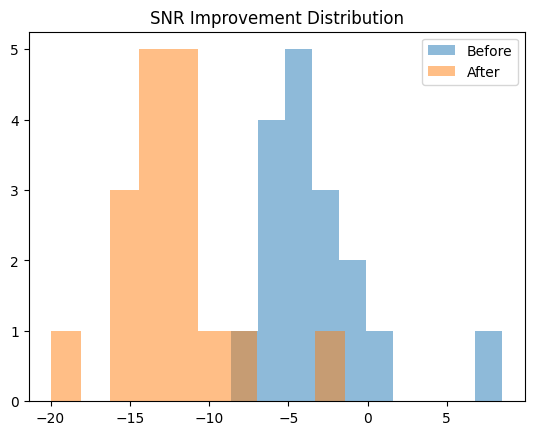

In [30]:
plt.hist(snr_before_list, alpha=0.5, label="Before")
plt.hist(snr_after_list, alpha=0.5, label="After")
plt.legend()
plt.title("SNR Improvement Distribution")
plt.show()


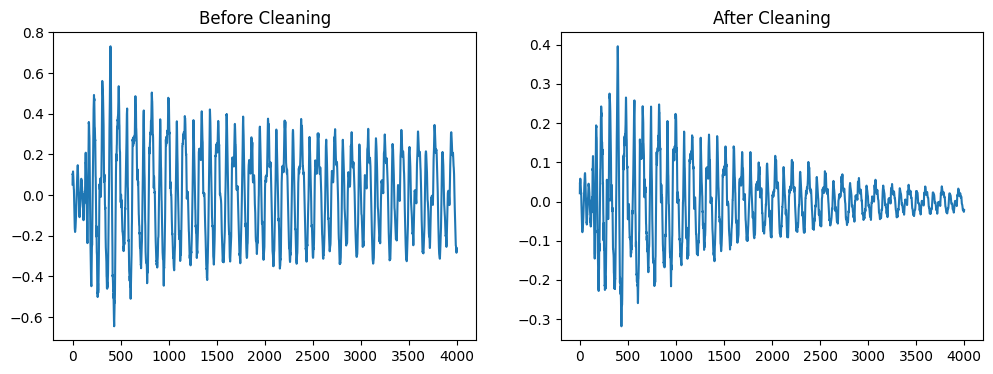

In [32]:
sample_file = os.listdir(input_folder)[0]

orig, clean, sr = clean_audio(os.path.join(input_folder, sample_file))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(orig[:4000])
plt.title("Before Cleaning")

plt.subplot(1,2,2)
plt.plot(clean[:4000])
plt.title("After Cleaning")

plt.show()
